# Ensemble Learning 
## Max Voting ( Classifier ) 

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns

In [36]:
x ,y = make_moons(n_samples=1000,noise=0.2)

In [37]:
df ={"x1" : x[:,0],"x2":x[:,1],"y":y}

In [38]:
dataset = pd.DataFrame(df)

In [39]:
dataset

,x1,x2,y
0,1.430082,-0.357508,1
1,1.723931,-0.180028,1
2,0.152125,0.740663,0
3,0.860955,-0.712004,1
4,-1.258340,-0.052838,0
...,...,...,...
995,0.128025,0.690766,0
996,-0.315711,1.141303,0
997,0.919371,0.818706,0
998,1.079472,-0.533279,1


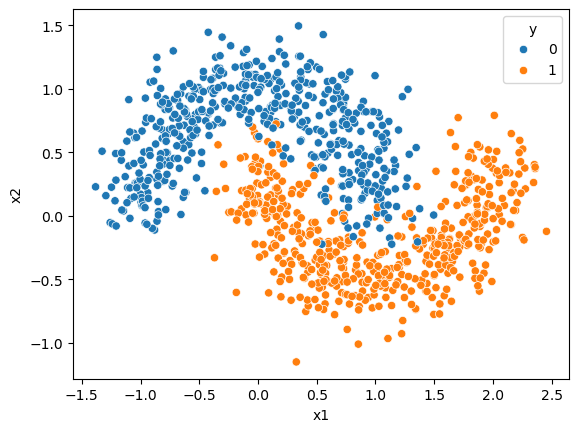

In [40]:
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()

In [41]:
x_a = dataset.iloc[:,:-1]

In [42]:
y_a = dataset["y"]

In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=42)

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [46]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt.score(x_train,y_train)*100,dt.score(x_test,y_test)*100

(100.0, 98.0)

In [47]:
sv = SVC()
sv.fit(x_train,y_train)
sv.score(x_train,y_train)*100,dt.score(x_test,y_test)*100

(96.125, 98.0)

In [48]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)
gnb.score(x_train,y_train)*100,dt.score(x_test,y_test)*100

(87.0, 98.0)

In [49]:
from sklearn.ensemble import VotingClassifier

In [52]:
li = [("dt1",DecisionTreeClassifier()),("sv1",SVC()),("gnb1",GaussianNB())]

In [54]:
vc = VotingClassifier(li)
vc.fit(x_train,y_train)

VotingClassifier(estimators=[('dt1', DecisionTreeClassifier()), ('sv1', SVC()),
                             ('gnb1', GaussianNB())])

In [56]:
vc.score(x_train,y_train)*100,  vc.score(x_train,y_train)*100

(97.375, 97.375)

In [60]:
prd = {"dt":dt.predict(x_test),"svm":sv.predict(x_test),"gnb":gnb.predict(x_test),"vc":vc.predict(x_test)}

In [61]:
pd.DataFrame(prd)

,dt,svm,gnb,vc
0,0,0,0,0
1,1,1,1,1
2,0,0,1,0
3,0,0,0,0
4,0,0,1,0
...,...,...,...,...
195,0,0,0,0
196,1,1,0,1
197,0,0,0,0
198,0,0,1,0
